In [ ]:
!pip -q install gymnasium

# MountainCar

## AUX Helper

In [ ]:
import numpy as np
import gymnasium as gym
import pickle

env = gym.make('MountainCar-v0')

# Discritize observation and action space in bins.
pos_space = np.linspace(-1.2, 0.6, 18)
vel_space = np.linspace(-0.07, 0.07, 28)

# given observation, returns what bin
def getState(observation):
    pos, vel = observation
    pos_bin = np.digitize(pos, pos_space)
    vel_bin = np.digitize(vel, vel_space)

    return (pos_bin, vel_bin)

# Creates a new empty Q-table for this environment
def createEmptyQTable():
    states = []
    for pos in range(len(pos_space) + 1):
        for vel in range(len(vel_space) + 1):
            states.append((pos,vel))

    Q = {}
    for state in states:
        for action in range(env.action_space.n):
            Q[state, action] = 0
    return Q

# Given a state and a set of actions
# returns action that has the highest Q-value
def maxAction(Q, state, actions=[0, 1, 2]):
    values = np.array([Q[state,a] for a in actions])
    action = np.argmax(values)
    return action

# Saves a variable as a file
def save_obj(obj, name ):
    with open(name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

# Load a variable from file
def load_obj(name ):
    with open(name + '.pkl', 'rb') as f:
        return pickle.load(f)

## Q-learning training

In [ ]:
import numpy as np
import gymnasium as gym
import random
import pickle


def train_qlearning(
    env_name='MountainCar-v0',
    pos_bins=18,
    vel_bins=28,
    alpha=0.1,
    gamma=0.9,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=None,
    episodes=50000,
    max_steps=1000,
    save_name='Q-table-Q-Learning'
):

    env = gym.make(env_name)
    env._max_episode_steps = max_steps

    # Discretization
    pos_space = np.linspace(env.observation_space.low[0],
                            env.observation_space.high[0],
                            pos_bins)
    vel_space = np.linspace(env.observation_space.low[1],
                            env.observation_space.high[1],
                            vel_bins)

    def getState(observation):
        pos, vel = observation
        pos_bin = np.digitize(pos, pos_space)
        vel_bin = np.digitize(vel, vel_space)
        return (pos_bin, vel_bin)

    # Create empty Q-table
    Q = {}
    for pos in range(len(pos_space) + 1):
        for vel in range(len(vel_space) + 1):
            for action in range(env.action_space.n):
                Q[(pos, vel), action] = 0

    def maxAction(state):
        values = np.array([Q[state, a] for a in range(env.action_space.n)])
        return np.argmax(values)

    epsilon = epsilon_start
    total_score = np.zeros(episodes)

    if epsilon_decay is None:
        epsilon_decay = (epsilon_start - epsilon_min) / episodes

    for i in range(episodes):

        if i % 500 == 0:
            print(f'[Q] episode={i} last_score={total_score[i-1] if i>0 else 0} epsilon={epsilon:.3f}')

        observation, info = env.reset()
        state = getState(observation)

        score = 0
        done = False

        while not done:

            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                action = maxAction(state)

            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = getState(next_observation)

            score += reward

            next_action = maxAction(next_state)

            Q[state, action] = Q[state, action] + alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state = next_state

        total_score[i] = score
        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    with open(save_name + '.pkl', 'wb') as f:
        pickle.dump(Q, f, pickle.HIGHEST_PROTOCOL)

    env.close()
    return Q, total_score

## SARSA training

In [ ]:
import numpy as np
import gymnasium as gym
import random
import pickle


def train_sarsa(
    env_name='MountainCar-v0',
    pos_bins=18,
    vel_bins=28,
    alpha=0.1,
    gamma=0.9,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=None,
    episodes=50000,
    max_steps=1000,
    save_name='Q-table-SARSA'
):

    env = gym.make(env_name)
    env._max_episode_steps = max_steps

    # Discretization
    pos_space = np.linspace(env.observation_space.low[0],
                            env.observation_space.high[0],
                            pos_bins)
    vel_space = np.linspace(env.observation_space.low[1],
                            env.observation_space.high[1],
                            vel_bins)

    def getState(observation):
        pos, vel = observation
        pos_bin = np.digitize(pos, pos_space)
        vel_bin = np.digitize(vel, vel_space)
        return (pos_bin, vel_bin)

    # Create empty Q-table
    Q = {}
    for pos in range(len(pos_space) + 1):
        for vel in range(len(vel_space) + 1):
            for action in range(env.action_space.n):
                Q[(pos, vel), action] = 0

    def maxAction(state):
        values = np.array([Q[state, a] for a in range(env.action_space.n)])
        return np.argmax(values)

    epsilon = epsilon_start
    total_score = np.zeros(episodes)

    if epsilon_decay is None:
        epsilon_decay = (epsilon_start - epsilon_min) / episodes

    for i in range(episodes):

        if i % 500 == 0:
            print(f'[SARSA] episode={i} last_score={total_score[i-1] if i>0 else 0} epsilon={epsilon:.3f}')

        observation, info = env.reset()
        state = getState(observation)

        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = maxAction(state)

        score = 0
        done = False

        while not done:

            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = getState(next_observation)

            if random.uniform(0, 1) < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = maxAction(next_state)

            score += reward

            Q[state, action] = Q[state, action] + alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state, action = next_state, next_action

        total_score[i] = score
        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    with open(save_name + '.pkl', 'wb') as f:
        pickle.dump(Q, f, pickle.HIGHEST_PROTOCOL)

    env.close()
    return Q, total_score

## Tweaking params and re-train models

In [ ]:
Q_q, scores_q = train_qlearning()

[Q] episode=0 last_score=0 epsilon=1.000
[Q] episode=500 last_score=-1000.0 epsilon=0.990
[Q] episode=1000 last_score=-1000.0 epsilon=0.980
[Q] episode=1500 last_score=-1000.0 epsilon=0.970
[Q] episode=2000 last_score=-1000.0 epsilon=0.960
[Q] episode=2500 last_score=-1000.0 epsilon=0.950
[Q] episode=3000 last_score=-1000.0 epsilon=0.941
[Q] episode=3500 last_score=-1000.0 epsilon=0.931
[Q] episode=4000 last_score=-1000.0 epsilon=0.921
[Q] episode=4500 last_score=-1000.0 epsilon=0.911
[Q] episode=5000 last_score=-1000.0 epsilon=0.901
[Q] episode=5500 last_score=-1000.0 epsilon=0.891
[Q] episode=6000 last_score=-1000.0 epsilon=0.881
[Q] episode=6500 last_score=-953.0 epsilon=0.871
[Q] episode=7000 last_score=-1000.0 epsilon=0.861
[Q] episode=7500 last_score=-1000.0 epsilon=0.851
[Q] episode=8000 last_score=-734.0 epsilon=0.842
[Q] episode=8500 last_score=-1000.0 epsilon=0.832
[Q] episode=9000 last_score=-1000.0 epsilon=0.822
[Q] episode=9500 last_score=-950.0 epsilon=0.812
[Q] episode=1

In [ ]:
Q_sarsa, scores_sarsa = train_sarsa()

[SARSA] episode=0 last_score=0 epsilon=1.000
[SARSA] episode=500 last_score=-1000.0 epsilon=0.990
[SARSA] episode=1000 last_score=-1000.0 epsilon=0.980
[SARSA] episode=1500 last_score=-1000.0 epsilon=0.970
[SARSA] episode=2000 last_score=-1000.0 epsilon=0.960
[SARSA] episode=2500 last_score=-1000.0 epsilon=0.950
[SARSA] episode=3000 last_score=-1000.0 epsilon=0.941
[SARSA] episode=3500 last_score=-1000.0 epsilon=0.931
[SARSA] episode=4000 last_score=-1000.0 epsilon=0.921
[SARSA] episode=4500 last_score=-1000.0 epsilon=0.911
[SARSA] episode=5000 last_score=-1000.0 epsilon=0.901
[SARSA] episode=5500 last_score=-1000.0 epsilon=0.891
[SARSA] episode=6000 last_score=-784.0 epsilon=0.881
[SARSA] episode=6500 last_score=-737.0 epsilon=0.871
[SARSA] episode=7000 last_score=-1000.0 epsilon=0.861
[SARSA] episode=7500 last_score=-1000.0 epsilon=0.851
[SARSA] episode=8000 last_score=-330.0 epsilon=0.842
[SARSA] episode=8500 last_score=-965.0 epsilon=0.832
[SARSA] episode=9000 last_score=-1000.0 ep

In [ ]:
Q_q_1, scores_q_1 = train_qlearning(
    alpha=0.05,
    gamma=0.95,
    epsilon_min=0.05,
    save_name="Q_a005_g095"
)

[Q] episode=0 last_score=0 epsilon=1.000
[Q] episode=500 last_score=-1000.0 epsilon=0.991
[Q] episode=1000 last_score=-1000.0 epsilon=0.981
[Q] episode=1500 last_score=-1000.0 epsilon=0.972
[Q] episode=2000 last_score=-1000.0 epsilon=0.962
[Q] episode=2500 last_score=-1000.0 epsilon=0.953
[Q] episode=3000 last_score=-1000.0 epsilon=0.943
[Q] episode=3500 last_score=-1000.0 epsilon=0.934
[Q] episode=4000 last_score=-1000.0 epsilon=0.924
[Q] episode=4500 last_score=-1000.0 epsilon=0.915
[Q] episode=5000 last_score=-1000.0 epsilon=0.905
[Q] episode=5500 last_score=-968.0 epsilon=0.896
[Q] episode=6000 last_score=-960.0 epsilon=0.886
[Q] episode=6500 last_score=-901.0 epsilon=0.877
[Q] episode=7000 last_score=-1000.0 epsilon=0.867
[Q] episode=7500 last_score=-1000.0 epsilon=0.858
[Q] episode=8000 last_score=-490.0 epsilon=0.848
[Q] episode=8500 last_score=-604.0 epsilon=0.839
[Q] episode=9000 last_score=-693.0 epsilon=0.829
[Q] episode=9500 last_score=-842.0 epsilon=0.820
[Q] episode=10000

In [ ]:
Q_q_2, scores_q_2 = train_qlearning(
    alpha=0.05,
    gamma=0.99,
    epsilon_min=0.05,
    save_name="Q_a005_g099"
)

[Q] episode=0 last_score=0 epsilon=1.000
[Q] episode=500 last_score=-1000.0 epsilon=0.991
[Q] episode=1000 last_score=-1000.0 epsilon=0.981
[Q] episode=1500 last_score=-1000.0 epsilon=0.972
[Q] episode=2000 last_score=-1000.0 epsilon=0.962
[Q] episode=2500 last_score=-1000.0 epsilon=0.953
[Q] episode=3000 last_score=-1000.0 epsilon=0.943
[Q] episode=3500 last_score=-1000.0 epsilon=0.934
[Q] episode=4000 last_score=-1000.0 epsilon=0.924
[Q] episode=4500 last_score=-1000.0 epsilon=0.915
[Q] episode=5000 last_score=-1000.0 epsilon=0.905
[Q] episode=5500 last_score=-1000.0 epsilon=0.896
[Q] episode=6000 last_score=-1000.0 epsilon=0.886
[Q] episode=6500 last_score=-854.0 epsilon=0.877
[Q] episode=7000 last_score=-811.0 epsilon=0.867
[Q] episode=7500 last_score=-1000.0 epsilon=0.858
[Q] episode=8000 last_score=-1000.0 epsilon=0.848
[Q] episode=8500 last_score=-1000.0 epsilon=0.839
[Q] episode=9000 last_score=-599.0 epsilon=0.829
[Q] episode=9500 last_score=-935.0 epsilon=0.820
[Q] episode=10

In [ ]:
Q_q_3, scores_q_3 = train_qlearning(
    alpha=0.20,
    gamma=0.95,
    epsilon_min=0.05,
    save_name="Q_a020_g095"
)

[Q] episode=0 last_score=0 epsilon=1.000
[Q] episode=500 last_score=-1000.0 epsilon=0.991
[Q] episode=1000 last_score=-1000.0 epsilon=0.981
[Q] episode=1500 last_score=-1000.0 epsilon=0.972
[Q] episode=2000 last_score=-1000.0 epsilon=0.962
[Q] episode=2500 last_score=-1000.0 epsilon=0.953
[Q] episode=3000 last_score=-1000.0 epsilon=0.943
[Q] episode=3500 last_score=-1000.0 epsilon=0.934
[Q] episode=4000 last_score=-1000.0 epsilon=0.924
[Q] episode=4500 last_score=-1000.0 epsilon=0.915
[Q] episode=5000 last_score=-1000.0 epsilon=0.905
[Q] episode=5500 last_score=-1000.0 epsilon=0.896
[Q] episode=6000 last_score=-1000.0 epsilon=0.886
[Q] episode=6500 last_score=-1000.0 epsilon=0.877
[Q] episode=7000 last_score=-1000.0 epsilon=0.867
[Q] episode=7500 last_score=-1000.0 epsilon=0.858
[Q] episode=8000 last_score=-895.0 epsilon=0.848
[Q] episode=8500 last_score=-1000.0 epsilon=0.839
[Q] episode=9000 last_score=-593.0 epsilon=0.829
[Q] episode=9500 last_score=-712.0 epsilon=0.820
[Q] episode=1

In [ ]:
Q_q_4, scores_q_4 = train_qlearning(
    alpha=0.20,
    gamma=0.99,
    epsilon_min=0.05,
    save_name="Q_a020_g099"
)

[Q] episode=0 last_score=0 epsilon=1.000
[Q] episode=500 last_score=-1000.0 epsilon=0.991
[Q] episode=1000 last_score=-1000.0 epsilon=0.981
[Q] episode=1500 last_score=-1000.0 epsilon=0.972
[Q] episode=2000 last_score=-1000.0 epsilon=0.962
[Q] episode=2500 last_score=-1000.0 epsilon=0.953
[Q] episode=3000 last_score=-1000.0 epsilon=0.943
[Q] episode=3500 last_score=-1000.0 epsilon=0.934
[Q] episode=4000 last_score=-1000.0 epsilon=0.924
[Q] episode=4500 last_score=-1000.0 epsilon=0.915
[Q] episode=5000 last_score=-1000.0 epsilon=0.905
[Q] episode=5500 last_score=-1000.0 epsilon=0.896
[Q] episode=6000 last_score=-1000.0 epsilon=0.886
[Q] episode=6500 last_score=-1000.0 epsilon=0.877
[Q] episode=7000 last_score=-1000.0 epsilon=0.867
[Q] episode=7500 last_score=-1000.0 epsilon=0.858
[Q] episode=8000 last_score=-832.0 epsilon=0.848
[Q] episode=8500 last_score=-1000.0 epsilon=0.839
[Q] episode=9000 last_score=-537.0 epsilon=0.829
[Q] episode=9500 last_score=-911.0 epsilon=0.820
[Q] episode=1

In [ ]:
Q_s_1, scores_s_1 = train_sarsa(
    alpha=0.05,
    gamma=0.95,
    epsilon_min=0.05,
    save_name="SARSA_a005_g095"
)

[SARSA] episode=0 last_score=0 epsilon=1.000
[SARSA] episode=500 last_score=-1000.0 epsilon=0.991
[SARSA] episode=1000 last_score=-1000.0 epsilon=0.981
[SARSA] episode=1500 last_score=-1000.0 epsilon=0.972
[SARSA] episode=2000 last_score=-1000.0 epsilon=0.962
[SARSA] episode=2500 last_score=-1000.0 epsilon=0.953
[SARSA] episode=3000 last_score=-1000.0 epsilon=0.943
[SARSA] episode=3500 last_score=-1000.0 epsilon=0.934
[SARSA] episode=4000 last_score=-1000.0 epsilon=0.924
[SARSA] episode=4500 last_score=-1000.0 epsilon=0.915
[SARSA] episode=5000 last_score=-1000.0 epsilon=0.905
[SARSA] episode=5500 last_score=-1000.0 epsilon=0.896
[SARSA] episode=6000 last_score=-1000.0 epsilon=0.886
[SARSA] episode=6500 last_score=-1000.0 epsilon=0.877
[SARSA] episode=7000 last_score=-1000.0 epsilon=0.867
[SARSA] episode=7500 last_score=-1000.0 epsilon=0.858
[SARSA] episode=8000 last_score=-670.0 epsilon=0.848
[SARSA] episode=8500 last_score=-1000.0 epsilon=0.839
[SARSA] episode=9000 last_score=-1000.0

In [ ]:
Q_s_2, scores_s_2 = train_sarsa(
    alpha=0.05,
    gamma=0.99,
    epsilon_min=0.05,
    save_name="SARSA_a005_g099"
)

[SARSA] episode=0 last_score=0 epsilon=1.000
[SARSA] episode=500 last_score=-1000.0 epsilon=0.991
[SARSA] episode=1000 last_score=-1000.0 epsilon=0.981
[SARSA] episode=1500 last_score=-1000.0 epsilon=0.972
[SARSA] episode=2000 last_score=-1000.0 epsilon=0.962
[SARSA] episode=2500 last_score=-1000.0 epsilon=0.953
[SARSA] episode=3000 last_score=-1000.0 epsilon=0.943
[SARSA] episode=3500 last_score=-1000.0 epsilon=0.934
[SARSA] episode=4000 last_score=-1000.0 epsilon=0.924
[SARSA] episode=4500 last_score=-1000.0 epsilon=0.915
[SARSA] episode=5000 last_score=-1000.0 epsilon=0.905
[SARSA] episode=5500 last_score=-1000.0 epsilon=0.896
[SARSA] episode=6000 last_score=-826.0 epsilon=0.886
[SARSA] episode=6500 last_score=-1000.0 epsilon=0.877
[SARSA] episode=7000 last_score=-1000.0 epsilon=0.867
[SARSA] episode=7500 last_score=-1000.0 epsilon=0.858
[SARSA] episode=8000 last_score=-1000.0 epsilon=0.848
[SARSA] episode=8500 last_score=-629.0 epsilon=0.839
[SARSA] episode=9000 last_score=-1000.0 

In [ ]:
Q_s_3, scores_s_3 = train_sarsa(
    alpha=0.20,
    gamma=0.95,
    epsilon_min=0.05,
    save_name="SARSA_a020_g095"
)

[SARSA] episode=0 last_score=0 epsilon=1.000
[SARSA] episode=500 last_score=-1000.0 epsilon=0.991
[SARSA] episode=1000 last_score=-1000.0 epsilon=0.981
[SARSA] episode=1500 last_score=-1000.0 epsilon=0.972
[SARSA] episode=2000 last_score=-1000.0 epsilon=0.962
[SARSA] episode=2500 last_score=-1000.0 epsilon=0.953
[SARSA] episode=3000 last_score=-1000.0 epsilon=0.943
[SARSA] episode=3500 last_score=-1000.0 epsilon=0.934
[SARSA] episode=4000 last_score=-1000.0 epsilon=0.924
[SARSA] episode=4500 last_score=-1000.0 epsilon=0.915
[SARSA] episode=5000 last_score=-1000.0 epsilon=0.905
[SARSA] episode=5500 last_score=-1000.0 epsilon=0.896
[SARSA] episode=6000 last_score=-1000.0 epsilon=0.886
[SARSA] episode=6500 last_score=-1000.0 epsilon=0.877
[SARSA] episode=7000 last_score=-842.0 epsilon=0.867
[SARSA] episode=7500 last_score=-1000.0 epsilon=0.858
[SARSA] episode=8000 last_score=-1000.0 epsilon=0.848
[SARSA] episode=8500 last_score=-1000.0 epsilon=0.839
[SARSA] episode=9000 last_score=-1000.0

In [ ]:
Q_s_4, scores_s_4 = train_sarsa(
    alpha=0.20,
    gamma=0.99,
    epsilon_min=0.05,
    save_name="SARSA_a020_g099"
)

[SARSA] episode=0 last_score=0 epsilon=1.000
[SARSA] episode=500 last_score=-1000.0 epsilon=0.991
[SARSA] episode=1000 last_score=-1000.0 epsilon=0.981
[SARSA] episode=1500 last_score=-1000.0 epsilon=0.972
[SARSA] episode=2000 last_score=-1000.0 epsilon=0.962
[SARSA] episode=2500 last_score=-1000.0 epsilon=0.953
[SARSA] episode=3000 last_score=-1000.0 epsilon=0.943
[SARSA] episode=3500 last_score=-1000.0 epsilon=0.934
[SARSA] episode=4000 last_score=-1000.0 epsilon=0.924
[SARSA] episode=4500 last_score=-1000.0 epsilon=0.915
[SARSA] episode=5000 last_score=-798.0 epsilon=0.905
[SARSA] episode=5500 last_score=-1000.0 epsilon=0.896
[SARSA] episode=6000 last_score=-1000.0 epsilon=0.886
[SARSA] episode=6500 last_score=-1000.0 epsilon=0.877
[SARSA] episode=7000 last_score=-1000.0 epsilon=0.867
[SARSA] episode=7500 last_score=-1000.0 epsilon=0.858
[SARSA] episode=8000 last_score=-1000.0 epsilon=0.848
[SARSA] episode=8500 last_score=-1000.0 epsilon=0.839
[SARSA] episode=9000 last_score=-1000.0

## Performance Comparison

In [ ]:
import numpy as np
import pandas as pd
import gymnasium as gym

def evaluate_saved_qtable(pkl_filename, episodes=50, max_steps=200, seed=123):
    Q = load_obj(pkl_filename.replace(".pkl",""))

    env = gym.make("MountainCar-v0")
    env._max_episode_steps = max_steps

    rewards = []
    success = 0

    for ep in range(episodes):
        obs, info = env.reset(seed=seed + ep)
        state = getState(obs)

        done = False
        total_reward = 0

        while not done:
            action = maxAction(Q, state)  # greedy policy (ε=0)
            obs, r, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += r
            state = getState(obs)

        rewards.append(total_reward)
        if terminated:
            success += 1

    env.close()

    return float(np.mean(rewards)), float(np.std(rewards)), success / episodes


models = [
    # Baselines
    ("Q-learning (baseline)", "Q-table-Q-Learning.pkl", "Q-learning"),
    ("SARSA (baseline)",      "Q-table-SARSA.pkl",      "SARSA"),

    # Q-learning tuned cases
    ("Q a=0.05 g=0.95", "Q_a005_g095.pkl", "Q-learning"),
    ("Q a=0.05 g=0.99", "Q_a005_g099.pkl", "Q-learning"),
    ("Q a=0.20 g=0.95", "Q_a020_g095.pkl", "Q-learning"),
    ("Q a=0.20 g=0.99", "Q_a020_g099.pkl", "Q-learning"),

    # SARSA tuned cases
    ("S a=0.05 g=0.95", "SARSA_a005_g095.pkl", "SARSA"),
    ("S a=0.05 g=0.99", "SARSA_a005_g099.pkl", "SARSA"),
    ("S a=0.20 g=0.95", "SARSA_a020_g095.pkl", "SARSA"),
    ("S a=0.20 g=0.99", "SARSA_a020_g099.pkl", "SARSA"),
]

rows = []
for label, fname, algo in models:
    mean_r, std_r, succ = evaluate_saved_qtable(fname, episodes=50, max_steps=200, seed=123)
    rows.append({
        "Algorithm": algo,
        "Model": label,
        "File": fname,
        "Mean Reward": mean_r,
        "Std": std_r,
        "Success Rate": succ
    })

df = pd.DataFrame(rows).sort_values(["Algorithm", "Mean Reward"], ascending=[True, False])
df

,Algorithm,Model,File,Mean Reward,Std,Success Rate
3,Q-learning,Q a=0.05 g=0.99,Q_a005_g099.pkl,-110.52,13.973174,1.00
0,Q-learning,Q-learning (baseline),Q-table-Q-Learning.pkl,-146.46,16.891667,1.00
2,Q-learning,Q a=0.05 g=0.95,Q_a005_g095.pkl,-154.60,13.598529,1.00
4,Q-learning,Q a=0.20 g=0.95,Q_a020_g095.pkl,-187.32,22.661368,0.26
5,Q-learning,Q a=0.20 g=0.99,Q_a020_g099.pkl,-195.80,4.741308,0.48
7,SARSA,S a=0.05 g=0.99,SARSA_a005_g099.pkl,-146.38,18.834957,1.00
8,SARSA,S a=0.20 g=0.95,SARSA_a020_g095.pkl,-154.30,12.085115,1.00
9,SARSA,S a=0.20 g=0.99,SARSA_a020_g099.pkl,-157.58,19.789987,0.96
6,SARSA,S a=0.05 g=0.95,SARSA_a005_g095.pkl,-168.02,22.257125,0.78
1,SARSA,SARSA (baseline),Q-table-SARSA.pkl,-168.98,24.319120,0.96


In [ ]:
best_q = df[df["Algorithm"]=="Q-learning"].iloc[0]
best_s = df[df["Algorithm"]=="SARSA"].iloc[0]

print("Best Q-learning:", best_q["Model"], "| mean=", best_q["Mean Reward"], "| std=", best_q["Std"], "| success=", best_q["Success Rate"])
print("Best SARSA     :", best_s["Model"], "| mean=", best_s["Mean Reward"], "| std=", best_s["Std"], "| success=", best_s["Success Rate"])

Best Q-learning: Q a=0.05 g=0.99 | mean= -110.52 | std= 13.97317429934945 | success= 1.0
Best SARSA     : S a=0.05 g=0.99 | mean= -146.38 | std= 18.834956862175183 | success= 1.0


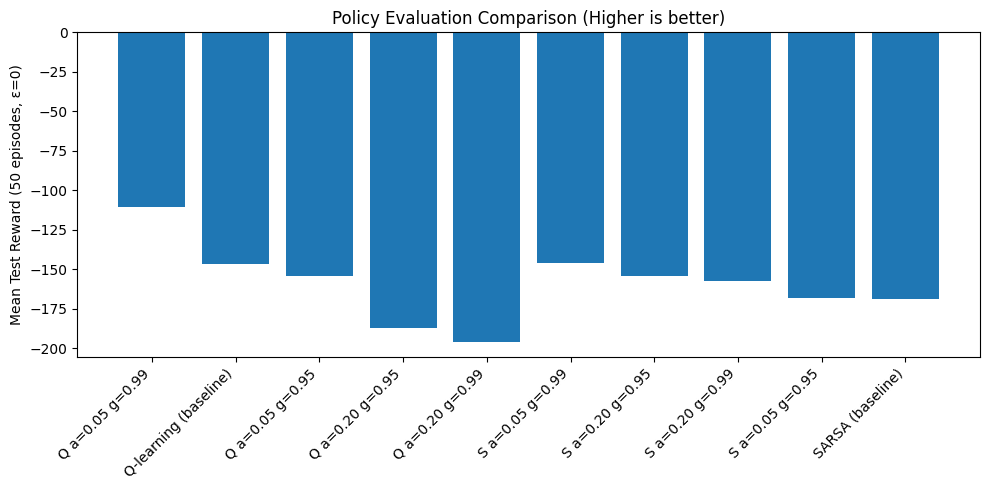

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df["Model"], df["Mean Reward"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Test Reward (50 episodes, ε=0)")
plt.title("Policy Evaluation Comparison (Higher is better)")
plt.tight_layout()
plt.show()

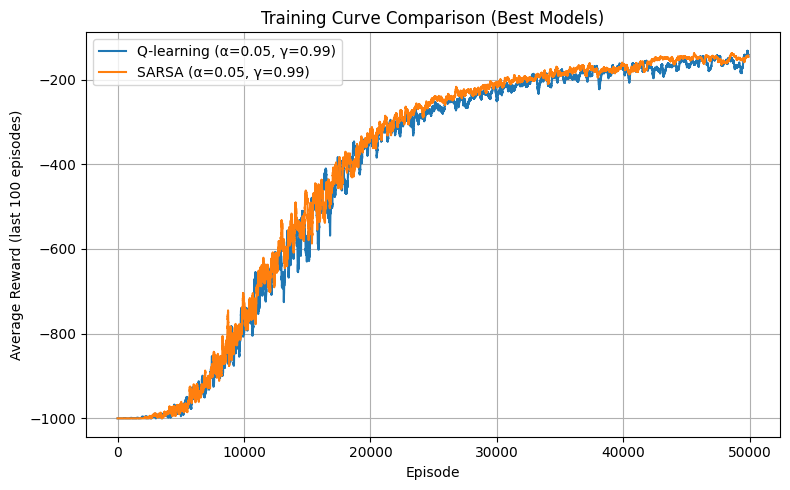

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, window=100):
    return np.convolve(x, np.ones(window)/window, mode="valid")

window = 100

best_q_curve = moving_average(scores_q_2, window)   # Q a=0.05 g=0.99
best_s_curve = moving_average(scores_s_2, window)   # S a=0.05 g=0.99

plt.figure(figsize=(8,5))
plt.plot(best_q_curve, label="Q-learning (α=0.05, γ=0.99)")
plt.plot(best_s_curve, label="SARSA (α=0.05, γ=0.99)")

plt.xlabel("Episode")
plt.ylabel(f"Average Reward (last {window} episodes)")
plt.title("Training Curve Comparison (Best Models)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# FrozenLake

In [ ]:
import gymnasium as gym
import numpy as np
import random
import pickle
import matplotlib.pyplot as plt

## Helper functions

In [ ]:
def save_obj(obj, name):
    with open(name + ".pkl", "wb") as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def load_obj(name):
    with open(name + ".pkl", "rb") as f:
        return pickle.load(f)

## Q-learning training

In [ ]:
def train_qlearning_frozenlake(
    env_name="FrozenLake-v1",
    is_slippery=True,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=None,
    episodes=50000,
    max_steps=1000,
    save_name="FL_Q"
):
    env = gym.make(env_name, is_slippery=is_slippery)
    nS = env.observation_space.n
    nA = env.action_space.n

    Q = np.zeros((nS, nA))
    epsilon = epsilon_start

    if epsilon_decay is None:
        epsilon_decay = (epsilon_start - epsilon_min) / episodes

    rewards_per_ep = np.zeros(episodes)

    for ep in range(episodes):
        state, info = env.reset()
        done = False
        total_reward = 0

        for _ in range(max_steps):
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state]))

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward

            best_next_action = int(np.argmax(Q[next_state]))
            Q[state, action] = Q[state, action] + alpha * (
                reward + gamma * Q[next_state, best_next_action] - Q[state, action]
            )

            state = next_state
            if done:
                break

        rewards_per_ep[ep] = total_reward
        epsilon = max(epsilon - epsilon_decay, epsilon_min)

        if ep % 500 == 0:
            print(f"[FL Q] ep={ep} reward={total_reward} eps={epsilon:.3f}")

    env.close()
    save_obj(Q, save_name)
    return Q, rewards_per_ep

## SARSA training

In [ ]:
def train_sarsa_frozenlake(
    env_name="FrozenLake-v1",
    is_slippery=True,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=None,
    episodes=50000,
    max_steps=1000,
    save_name="FL_SARSA"
):
    env = gym.make(env_name, is_slippery=is_slippery)
    nS = env.observation_space.n
    nA = env.action_space.n

    Q = np.zeros((nS, nA))
    epsilon = epsilon_start

    if epsilon_decay is None:
        epsilon_decay = (epsilon_start - epsilon_min) / episodes

    rewards_per_ep = np.zeros(episodes)

    for ep in range(episodes):
        state, info = env.reset()

        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[state]))

        done = False
        total_reward = 0

        for _ in range(max_steps):
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward

            if random.uniform(0, 1) < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = int(np.argmax(Q[next_state]))

            Q[state, action] = Q[state, action] + alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state, action = next_state, next_action
            if done:
                break

        rewards_per_ep[ep] = total_reward
        epsilon = max(epsilon - epsilon_decay, epsilon_min)

        if ep % 500 == 0:
            print(f"[FL SARSA] ep={ep} reward={total_reward} eps={epsilon:.3f}")

    env.close()
    save_obj(Q, save_name)
    return Q, rewards_per_ep

## Evaluation

In [ ]:
def evaluate_frozenlake(Q, env_name="FrozenLake-v1", is_slippery=True, episodes=200, max_steps=100, seed=123):
    env = gym.make(env_name, is_slippery=is_slippery)
    successes = 0

    for ep in range(episodes):
        state, info = env.reset(seed=seed + ep)
        done = False

        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            if done:
                if reward == 1:
                    successes += 1
                break

    env.close()
    return successes / episodes

## Baseline models training

In [ ]:
Q_fl_q, rewards_fl_q = train_qlearning_frozenlake(save_name="FL_Q_baseline")
Q_fl_s, rewards_fl_s = train_sarsa_frozenlake(save_name="FL_SARSA_baseline")

sr_q = evaluate_frozenlake(Q_fl_q)
sr_s = evaluate_frozenlake(Q_fl_s)

print("Baseline Q-learning success rate:", sr_q)
print("Baseline SARSA success rate    :", sr_s)

[FL Q] ep=0 reward=0 eps=1.000
[FL Q] ep=500 reward=0 eps=0.990
[FL Q] ep=1000 reward=1 eps=0.980
[FL Q] ep=1500 reward=0 eps=0.970
[FL Q] ep=2000 reward=0 eps=0.960
[FL Q] ep=2500 reward=0 eps=0.950
[FL Q] ep=3000 reward=0 eps=0.941
[FL Q] ep=3500 reward=0 eps=0.931
[FL Q] ep=4000 reward=0 eps=0.921
[FL Q] ep=4500 reward=0 eps=0.911
[FL Q] ep=5000 reward=1 eps=0.901
[FL Q] ep=5500 reward=0 eps=0.891
[FL Q] ep=6000 reward=0 eps=0.881
[FL Q] ep=6500 reward=0 eps=0.871
[FL Q] ep=7000 reward=1 eps=0.861
[FL Q] ep=7500 reward=0 eps=0.851
[FL Q] ep=8000 reward=1 eps=0.842
[FL Q] ep=8500 reward=0 eps=0.832
[FL Q] ep=9000 reward=0 eps=0.822
[FL Q] ep=9500 reward=0 eps=0.812
[FL Q] ep=10000 reward=0 eps=0.802
[FL Q] ep=10500 reward=0 eps=0.792
[FL Q] ep=11000 reward=0 eps=0.782
[FL Q] ep=11500 reward=0 eps=0.772
[FL Q] ep=12000 reward=0 eps=0.762
[FL Q] ep=12500 reward=0 eps=0.752
[FL Q] ep=13000 reward=0 eps=0.743
[FL Q] ep=13500 reward=0 eps=0.733
[FL Q] ep=14000 reward=0 eps=0.723
[FL Q] ep

## Tweaking params and re-train models

In [ ]:
cases = [
    {"alpha": 0.1, "gamma": 0.99, "epsilon_min": 0.05},
    {"alpha": 0.2, "gamma": 0.99, "epsilon_min": 0.01},
    {"alpha": 0.2, "gamma": 0.99, "epsilon_min": 0.05},
]

rows = []

for i, c in enumerate(cases, start=1):
    # Q-learning
    q_name = f"FL_Q_t{i}"
    Qq, rq = train_qlearning_frozenlake(
        alpha=c["alpha"], gamma=c["gamma"], epsilon_min=c["epsilon_min"],
        save_name=q_name
    )
    q_sr = evaluate_frozenlake(Qq)
    rows.append({"Algo":"Q-learning", "Case":f"Q{i}", **c, "SuccessRate":q_sr})

    # SARSA
    s_name = f"FL_SARSA_t{i}"
    Qs, rs = train_sarsa_frozenlake(
        alpha=c["alpha"], gamma=c["gamma"], epsilon_min=c["epsilon_min"],
        save_name=s_name
    )
    s_sr = evaluate_frozenlake(Qs)
    rows.append({"Algo":"SARSA", "Case":f"S{i}", **c, "SuccessRate":s_sr})

import pandas as pd
df = pd.DataFrame(rows).sort_values(["Algo","SuccessRate"], ascending=[True, False])
df

[FL Q] ep=0 reward=0 eps=1.000
[FL Q] ep=500 reward=0 eps=0.990
[FL Q] ep=1000 reward=0 eps=0.981
[FL Q] ep=1500 reward=0 eps=0.971
[FL Q] ep=2000 reward=0 eps=0.962
[FL Q] ep=2500 reward=0 eps=0.952
[FL Q] ep=3000 reward=0 eps=0.943
[FL Q] ep=3500 reward=0 eps=0.933
[FL Q] ep=4000 reward=0 eps=0.924
[FL Q] ep=4500 reward=0 eps=0.914
[FL Q] ep=5000 reward=0 eps=0.905
[FL Q] ep=5500 reward=0 eps=0.895
[FL Q] ep=6000 reward=0 eps=0.886
[FL Q] ep=6500 reward=0 eps=0.876
[FL Q] ep=7000 reward=0 eps=0.867
[FL Q] ep=7500 reward=0 eps=0.857
[FL Q] ep=8000 reward=0 eps=0.848
[FL Q] ep=8500 reward=0 eps=0.838
[FL Q] ep=9000 reward=0 eps=0.829
[FL Q] ep=9500 reward=0 eps=0.819
[FL Q] ep=10000 reward=0 eps=0.810
[FL Q] ep=10500 reward=0 eps=0.800
[FL Q] ep=11000 reward=0 eps=0.791
[FL Q] ep=11500 reward=0 eps=0.781
[FL Q] ep=12000 reward=0 eps=0.772
[FL Q] ep=12500 reward=0 eps=0.762
[FL Q] ep=13000 reward=0 eps=0.753
[FL Q] ep=13500 reward=0 eps=0.743
[FL Q] ep=14000 reward=0 eps=0.734
[FL Q] ep

,Algo,Case,alpha,gamma,epsilon_min,SuccessRate
2,Q-learning,Q2,0.2,0.99,0.01,0.780
4,Q-learning,Q3,0.2,0.99,0.05,0.465
0,Q-learning,Q1,0.1,0.99,0.05,0.420
1,SARSA,S1,0.1,0.99,0.05,0.780
3,SARSA,S2,0.2,0.99,0.01,0.780
5,SARSA,S3,0.2,0.99,0.05,0.700


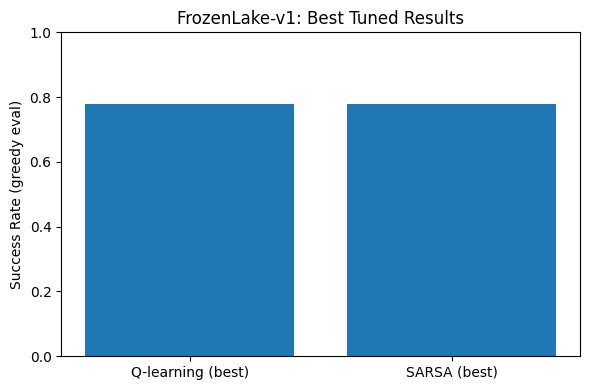

Best Q: {'Algo': 'Q-learning', 'Case': 'Q1', 'alpha': 0.1, 'gamma': 0.99, 'epsilon_min': 0.01, 'SuccessRate': 0.78}
Best S: {'Algo': 'SARSA', 'Case': 'S1', 'alpha': 0.1, 'gamma': 0.99, 'epsilon_min': 0.01, 'SuccessRate': 0.78}


In [ ]:
best_q = df[df["Algo"]=="Q-learning"].iloc[0]
best_s = df[df["Algo"]=="SARSA"].iloc[0]

plt.figure(figsize=(6,4))
plt.bar(["Q-learning (best)", "SARSA (best)"], [best_q["SuccessRate"], best_s["SuccessRate"]])
plt.ylabel("Success Rate (greedy eval)")
plt.title("FrozenLake-v1: Best Tuned Results")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

print("Best Q:", best_q.to_dict())
print("Best S:", best_s.to_dict())

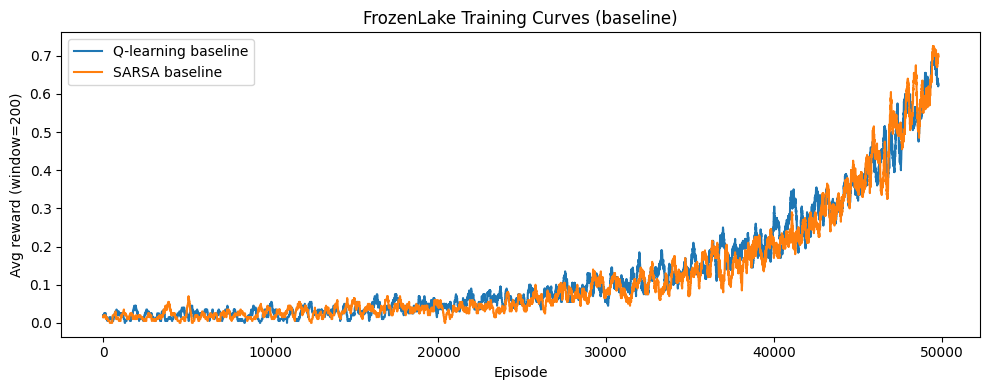

In [ ]:
def moving_average(x, w=200):
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(10,4))
plt.plot(moving_average(rewards_fl_q, 200), label="Q-learning baseline")
plt.plot(moving_average(rewards_fl_s, 200), label="SARSA baseline")
plt.xlabel("Episode")
plt.ylabel("Avg reward (window=200)")
plt.title("FrozenLake Training Curves (baseline)")
plt.legend()
plt.tight_layout()
plt.show()